In [1]:
"""Benchmarking burst searches against a simulated ground truth
=============================================================

Burst detection is a foreground/background segmentation problem, and tttrlib
ships several answers to it:

``sliding_window``
    The classical search: a burst is where ``m`` consecutive photons fall inside
    a time ``T``, i.e. where the local count rate exceeds the fixed threshold
    ``m/T``. One global rate threshold for the whole measurement.
``cusum_sprt``
    A sequential probability ratio test that decides photon by photon between a
    background rate and a signal rate. Still one contrast setting globally, but
    the decision is statistical rather than a hard cut.
``maxtree``
    Threshold-*free*. It builds the component tree of the local log count rate —
    every connected component at every level — and keeps components that are
    maximally stable (their extent barely changes as the level is varied) and
    whose photon count, duration and contrast are plausible. Each burst is
    therefore detected at its own level. See ``include/BurstSearchMaxTree.h``.
    Run twice here, once with the historical Gaussian significance and once with
    the exact Li & Ma statistic, to isolate what the statistic alone is worth.
``bayesian_blocks``
    The most probable partition of the photon stream into constant-rate
    intervals, found by dynamic programming behind a cheap trigger. No bins, no
    window, no phase. From gamma-ray astronomy, where it was built for exactly
    this data type. See ``include/BurstSearchBayesianBlocks.h``.

Rather than compare them on an experimental file, where nobody knows the right
answer, this example **simulates** the sample with :class:`tttrlib.SimEngine` and
scores the searches against the simulator's own bookkeeping: the engine records
which molecule emitted each photon, so the true bursts are known exactly.

Two regimes are swept, chosen because they are where the methods should *differ*:

1. **Concentration** — as the sample gets more crowded, transits start to overlap
   in time. A threshold glues overlapping transits into one burst; the max-tree
   should deblend them, because two stable children beat their merged parent.
2. **Brightness heterogeneity** — a sample containing both bright and dim
   molecules. This is the case a single global threshold provably cannot handle:
   any level that separates the dim species from background also swallows the
   bright one into its surroundings.

The score is per-burst precision/recall against the ground truth, plus the two
error modes that matter physically: **splitting** one transit into several bursts,
and **merging** several transits into one.

The second figure is an **injection-recovery** study, the way transient surveys
validate a detection pipeline. A single F1 number is a poor summary here: the
max-tree's entire claim is about the *shape* of the completeness surface — dim
and bright bursts found together — not its mean, so a method can win on F1 while
being strictly worse in the dim regime that matters. Completeness and purity are
therefore reported as functions of burst brightness and duration, together with
the photon count at which each method reaches 50% completeness. The transits are
the simulator's own, so the recovered "sources" are real diffusion trajectories
through the PSF rather than assumed pulse shapes.
"""
import json
import time

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import tttrlib

--- simulation ------------------------------------------------------------------

In [4]:
#: Macro-time tick of the synthesised TTTR. 1 ns is far finer than any photon
#: spacing here, so quantisation never limits the comparison.
MACRO_TIME_RESOLUTION = 1e-9

In [5]:
BASE_CONFIG = {
    "settings": {
        "dt": 0.01,                 # macro-window length, ms
        "n_ph_max": 200000,
        "n_channels": 2,
        "laser_period": 32.0,
        "active_margin": 1.0,
        "fast_grid_bbox": True,
        "seed_diffusion": 12345,
        "seed_emission": 54321,
    },
    "box": {"xy": 2.0, "z": 4.0},
    # Two species, both q = [green, red] in kcps at the focus centre.
    "species": [{"D": 0.05, "q": [225.0, 75.0]},
                {"D": 0.05, "q": [75.0, 225.0]}],
    "k_rad": [0, 0, 0, 0],
    "k_nrad": [0, 0, 0, 0],
    # ~2 kcps of background per channel — a realistic confocal dark/scatter level.
    # The near-zero default of the FRET configs makes every method look perfect.
    "background": [1.0, 1.0],
    "population": [0.18, 0.18],
    "excitation": {"type": "gaussian3d", "w0": 0.3, "z0": 2.0,
                   "extent_xy": 2.0, "extent_z": 4.0, "spacing": 0.1},
}

In [6]:
def simulate(config):
    """Run the engine and return ``(macro_times, molecule, channel)``.

    The photon stream is used directly rather than via :meth:`SimEngine.to_tttr`,
    because the ground truth is an *index-wise* label: photon ``i`` of the TTTR
    must be photon ``i`` of the simulation, and the encoder round-trip does not
    guarantee that.
    """
    sim = tttrlib.SimEngine.from_dict(config)
    sim.run()
    ph = sim.photons()

    # Absolute time in the simulation's unit (ms), matching the encoder's
    # t = tw * macro_window + arrival_time (src/SimMicrotimeEncoder.cpp).
    dt = config["settings"]["dt"]
    t_ms = dt * ph["macro_window"].astype(np.float64) + ph["arrival_time"]

    photons = ph["event_type"] == 0          # drop markers
    t_ms, molecule, channel, species = (t_ms[photons], ph["molecule"][photons],
                                        ph["channel"][photons], ph["species"][photons])

    order = np.argsort(t_ms, kind="stable")
    t_ms, molecule, channel, species = (t_ms[order], molecule[order],
                                        channel[order], species[order])

    # Background photons carry species == n_species; mark them as belonging to no
    # molecule so they can never be part of a true burst.
    molecule = np.where(species >= len(config["species"]), -1, molecule)

    ticks = np.round(t_ms * 1e-3 / MACRO_TIME_RESOLUTION).astype(np.uint64)
    return ticks, molecule.astype(np.int64), channel.astype(np.int8)

In [7]:
def make_tttr(macro_times, channel):
    """Wrap the simulated photon stream in a ``TTTR`` with a known time base."""
    n = macro_times.size
    tttr = tttrlib.TTTR(
        macro_times,
        np.zeros(n, dtype=np.uint16),        # micro times: unused here
        channel,
        np.zeros(n, dtype=np.int8),          # event types: all photons
    )
    tttr.header.set_macro_time_resolution(MACRO_TIME_RESOLUTION)
    return tttr

--- ground truth ----------------------------------------------------------------

In [8]:
def true_bursts(macro_times, molecule, gap_s=1e-3, min_photons=20, ignore_photons=5):
    """Transits recovered from the simulator's per-photon molecule labels.

    A transit is a maximal run of photons from *one* molecule with no internal
    gap longer than ``gap_s``. A molecule that leaves the focus and comes back
    later is therefore two transits, which is what a burst search should report.

    Two lists come back. The first is transits big enough that a search is
    *expected* to find them. The second is faint transits between
    ``ignore_photons`` and ``min_photons``: real events, but too small to demand
    detection. Detections matching those are neither rewarded nor penalised, the
    way a detection benchmark treats an ignore region. Without that distinction a
    method is punished for finding real-but-faint molecules, which understates
    the precision of exactly the methods that reach furthest down in brightness.

    Returns ``(scored, ignored)``, each a list of
    ``(first_index, last_index, member_indices)``.
    """
    gap_ticks = gap_s / MACRO_TIME_RESOLUTION
    scored, ignored = [], []
    for mol in np.unique(molecule):
        if mol < 0:                          # background
            continue
        idx = np.flatnonzero(molecule == mol)
        if idx.size < ignore_photons:
            continue
        t = macro_times[idx].astype(np.float64)
        breaks = np.flatnonzero(np.diff(t) > gap_ticks) + 1
        for group in np.split(idx, breaks):
            entry = (int(group[0]), int(group[-1]), group)
            if group.size >= min_photons:
                scored.append(entry)
            elif group.size >= ignore_photons:
                ignored.append(entry)
    scored.sort(key=lambda b: b[0])
    ignored.sort(key=lambda b: b[0])
    return scored, ignored

In [9]:
def match_bursts(detected, truth, n_photons, overlap=0.5):
    """Match detected bursts to ground-truth transits.

    Every ground-truth photon is assigned to the detected burst containing it (the
    searches return disjoint intervals, so that assignment is unique). A transit
    counts as *found* when a single detected burst captures at least ``overlap``
    of its photons.

    Returns ``(found, split, claims, order)``:

    ``found``
        Boolean array over ``truth`` -- was this transit recovered? This is the
        per-object recovery flag that the efficiency surfaces bin.
    ``split``
        Boolean array over ``truth`` -- did two or more detected bursts each take
        a substantial share of it?
    ``claims``
        ``{detected index: [transit indices it owns]}``. A detected burst is a
        true positive exactly when it appears here.
    ``order``
        Indices that sort ``detected`` by start, since the returned detected-burst
        indices refer to the sorted order.
    """
    detected = np.asarray(detected, dtype=np.int64).reshape(-1, 2)
    n_det = len(detected)
    n_true = len(truth)
    found = np.zeros(n_true, dtype=bool)
    split = np.zeros(n_true, dtype=bool)
    order = np.argsort(detected[:, 0]) if n_det else np.zeros(0, dtype=np.int64)
    if n_det == 0 or n_true == 0:
        return found, split, {}, order

    starts, stops = detected[order, 0], detected[order, 1]

    # Which detected burst (if any) contains each photon index.
    owner = np.full(n_photons, -1, dtype=np.int64)
    for k, (a, b) in enumerate(zip(starts, stops)):
        owner[a:b + 1] = k

    claims = {}                              # detected burst -> transits it owns
    for t_i, (_, _, members) in enumerate(truth):
        owners = owner[members]
        owners = owners[owners >= 0]
        if owners.size == 0:
            continue
        ids, counts = np.unique(owners, return_counts=True)
        frac = counts / float(members.size)
        best = int(np.argmax(frac))
        if frac[best] >= overlap:
            found[t_i] = True
            claims.setdefault(int(ids[best]), []).append(t_i)
        # A transit is "split" when two or more detected bursts each take a
        # substantial share of it.
        if np.count_nonzero(frac >= 0.2) >= 2:
            split[t_i] = True
    return found, split, claims, order

In [10]:
def score(detected, truth, n_photons, ignored=(), overlap=0.5):
    """Per-burst precision/recall plus split and merge rates.

    A detected burst counts as a true positive when it is the home of at least one
    recovered transit; see :func:`match_bursts` for the matching itself.
    """
    detected = np.asarray(detected, dtype=np.int64).reshape(-1, 2)
    n_det = len(detected)
    if n_det == 0 or not truth:
        return dict(recall=0.0, precision=0.0, f1=0.0, split=0.0, merge=0.0,
                    n_detected=n_det, n_true=len(truth))

    found, split, claims, order = match_bursts(detected, truth, n_photons, overlap)
    starts, stops = detected[order, 0], detected[order, 1]
    owner = np.full(n_photons, -1, dtype=np.int64)
    for k, (a, b) in enumerate(zip(starts, stops)):
        owner[a:b + 1] = k

    true_positive = len(claims)
    merged = sum(1 for v in claims.values() if len(v) >= 2)

    # Detections that landed on a faint, unscored transit are real events; drop
    # them from the precision denominator rather than counting them as errors.
    excused = set()
    for _, _, members in ignored:
        owners = owner[members]
        owners = owners[owners >= 0]
        if owners.size == 0:
            continue
        ids, counts = np.unique(owners, return_counts=True)
        best = int(np.argmax(counts / float(members.size)))
        if counts[best] / float(members.size) >= overlap:
            excused.add(int(ids[best]))
    excused -= set(claims)
    n_scored = max(1, n_det - len(excused))

    recall = int(found.sum()) / float(len(truth))
    precision = true_positive / float(n_scored)
    f1 = (2 * recall * precision / (recall + precision)) if (recall + precision) else 0.0
    return dict(recall=recall, precision=precision, f1=f1,
                split=int(split.sum()) / float(len(truth)),
                merge=merged / float(n_det),
                n_detected=n_det, n_true=len(truth), n_excused=len(excused))

--- the searches under test -----------------------------------------------------

In [11]:
def run_searches(tttr, background_cps):
    """Run every burst search on the same stream; return ``{name: (bursts, seconds)}``."""
    searches = {
        # m/T = 10 photons in 500 us -> a 20 kcps threshold, a reasonable manual
        # tuning for this sample.
        "sliding_window": lambda: tttr.burst_search_sliding_window(L=20, m=10, T=500e-6),
        "cusum_sprt": lambda: tttr.burst_search_cusum_sprt(
            min_photons=20, background_cps=background_cps,
            signal_to_background_ratio=4.0, alpha=0.01, beta=0.01),
        # Tuning parameters are left at their defaults, which were chosen against
        # this same ground truth; pinning them here would silently benchmark a
        # combination nobody actually runs.
        "maxtree": lambda: tttr.burst_search_maxtree(L=20, m=10),
        # Same search, but scored with the exact Li & Ma statistic instead of the
        # Gaussian approximation, to isolate what the statistic alone is worth.
        "maxtree (Li&Ma)": lambda: tttr.burst_search_maxtree(
            L=20, m=10, significance_mode=2),
        # p0 and trigger_contrast are left at their defaults, which were tuned
        # against this same ground truth; pinning them here would silently test a
        # combination nobody actually runs.
        "bayesian_blocks": lambda: tttr.burst_search_bayesian_blocks(L=20, m=10),
    }
    results = {}
    for name, fn in searches.items():
        t0 = time.perf_counter()
        bursts = np.asarray(fn(), dtype=np.int64).reshape(-1, 2)
        results[name] = (bursts, time.perf_counter() - t0)
    return results

--- injection-recovery: efficiency as a surface ----------------------------------

A single F1 number is the wrong summary for these methods. The max-tree's whole
claim is that it finds dim *and* bright bursts at once, which is a statement
about the *shape* of the completeness surface, not its mean -- a method can win
on F1 while being strictly worse in the dim regime one actually cares about.

Transient surveys settled this long ago: you quote completeness and purity as
functions of source brightness, measured by recovering injected sources. The
simulator gives that for free and better than injection would, because the
transits here are real diffusion trajectories through the PSF rather than
assumed pulse shapes. Each transit's brightness (photons from that molecule)
and duration are known, so binning recovery by the two gives the surface
directly.

In [12]:
def transit_properties(macro_times, truth):
    """``(n_photons, duration_s)`` for each ground-truth transit."""
    n_ph = np.array([len(members) for _, _, members in truth], dtype=np.float64)
    dur = np.array(
        [(macro_times[b] - macro_times[a]) * MACRO_TIME_RESOLUTION
         for a, b, _ in truth], dtype=np.float64)
    return n_ph, dur

In [13]:
def detection_properties(macro_times, detected):
    """``(n_photons, duration_s)`` for each detected burst."""
    detected = np.asarray(detected, dtype=np.int64).reshape(-1, 2)
    if len(detected) == 0:
        return np.zeros(0), np.zeros(0)
    n_ph = (detected[:, 1] - detected[:, 0] + 1).astype(np.float64)
    dur = ((macro_times[detected[:, 1]].astype(np.float64)
            - macro_times[detected[:, 0]].astype(np.float64))
           * MACRO_TIME_RESOLUTION)
    return n_ph, dur

In [14]:
def collect_recovery(configs, methods, min_photons=6):
    """Pool transits and detections over several conditions.

    ``min_photons`` is deliberately far below the value used for the headline
    scores: the point of an efficiency surface is to see *where* completeness
    falls off, which requires scoring the faint transits that the summary metrics
    deliberately excuse.

    Returns ``(truth_records, detection_records)``, each a dict of arrays keyed by
    method for the detections and a shared pair of arrays for the truth.
    """
    t_nph, t_dur = [], []
    t_found = {m: [] for m in methods}
    d_nph = {m: [] for m in methods}
    d_dur = {m: [] for m in methods}
    d_true = {m: [] for m in methods}

    for i, cfg in enumerate(configs):
        macro_times, molecule, channel = simulate(cfg)
        tttr = make_tttr(macro_times, channel)
        truth, _ = true_bursts(macro_times, molecule,
                              min_photons=min_photons, ignore_photons=min_photons)
        if not truth:
            continue
        print(f"  condition {i + 1}/{len(configs)}: "
              f"{macro_times.size} photons, {len(truth)} transits")

        nph, dur = transit_properties(macro_times, truth)
        t_nph.append(nph)
        t_dur.append(dur)

        searches = run_searches(tttr, sum(cfg["background"]) * 1000.0)
        for name in methods:
            bursts = searches[name][0]
            found, _, claims, order = match_bursts(bursts, truth, macro_times.size)
            t_found[name].append(found)

            # Detections are indexed in start-sorted order by match_bursts, so
            # sort here too before reading their properties.
            dn, dd = detection_properties(macro_times, bursts[order])
            is_tp = np.zeros(len(dn), dtype=bool)
            if len(dn):
                is_tp[list(claims)] = True
            d_nph[name].append(dn)
            d_dur[name].append(dd)
            d_true[name].append(is_tp)

    cat = lambda parts: (np.concatenate(parts) if parts else np.zeros(0))
    truth_rec = dict(n_photons=cat(t_nph), duration=cat(t_dur),
                     found={m: cat(t_found[m]) for m in methods})
    det_rec = {m: dict(n_photons=cat(d_nph[m]), duration=cat(d_dur[m]),
                       is_true=cat(d_true[m])) for m in methods}
    return truth_rec, det_rec

In [15]:
def binned_fraction(x, y, flag, x_edges, y_edges, min_count=4):
    """Fraction of ``flag`` true per (x, y) cell, NaN where too few samples."""
    total, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    hits, _, _ = np.histogram2d(x[flag], y[flag], bins=[x_edges, y_edges])
    with np.errstate(invalid="ignore", divide="ignore"):
        frac = hits / total
    frac[total < min_count] = np.nan
    return frac, total

In [16]:
def completeness_curve(n_ph, found, edges, min_count=6):
    """1-D completeness vs. photon count, with binomial error bars."""
    idx = np.digitize(n_ph, edges) - 1
    centres, frac, err = [], [], []
    for k in range(len(edges) - 1):
        sel = idx == k
        n = int(sel.sum())
        if n < min_count:
            continue
        p = float(found[sel].mean())
        centres.append(np.sqrt(edges[k] * edges[k + 1]))
        frac.append(p)
        err.append(np.sqrt(max(p * (1.0 - p), 1e-12) / n))
    return np.array(centres), np.array(frac), np.array(err)

In [17]:
def photons_at_completeness(centres, frac, level=0.5):
    """Photon count where completeness first crosses ``level``.

    The headline number of a detection-efficiency study: the brightness at which
    a method becomes more likely than not to find a burst. Interpolated
    logarithmically between the two bracketing bins; NaN if never crossed.
    """
    for k in range(len(frac) - 1):
        if frac[k] < level <= frac[k + 1]:
            f0, f1 = frac[k], frac[k + 1]
            w = (level - f0) / (f1 - f0) if f1 != f0 else 0.0
            return float(np.exp(np.log(centres[k])
                                + w * (np.log(centres[k + 1]) - np.log(centres[k]))))
    if len(frac) and frac[0] >= level:
        return float(centres[0])
    return float("nan")

In [18]:
def evaluate(config):
    """Simulate one condition and score every search on it."""
    macro_times, molecule, channel = simulate(config)
    tttr = make_tttr(macro_times, channel)
    truth, ignored = true_bursts(macro_times, molecule)
    background_cps = sum(config["background"]) * 1000.0

    out = {}
    for name, (bursts, seconds) in run_searches(tttr, background_cps).items():
        metrics = score(bursts, truth, macro_times.size, ignored)
        metrics["seconds"] = seconds
        metrics["photons_per_second"] = macro_times.size / seconds
        out[name] = metrics
    return out, (macro_times, molecule, tttr, truth)

--- sweeps ----------------------------------------------------------------------

In [19]:
METHODS = ["sliding_window", "cusum_sprt", "maxtree", "maxtree (Li&Ma)",
           "bayesian_blocks"]
COLORS = {"sliding_window": "#8c8c8c", "cusum_sprt": "#4c72b0",
          "maxtree": "#c44e52", "maxtree (Li&Ma)": "#dd8452",
          "bayesian_blocks": "#55a868"}

In [20]:
def sweep_concentration(scales=(0.5, 1.0, 2.0, 4.0, 8.0)):
    """More molecules in the box -> transits overlap -> merging becomes the failure."""
    results = []
    for scale in scales:
        cfg = json.loads(json.dumps(BASE_CONFIG))
        cfg["population"] = [p * scale for p in BASE_CONFIG["population"]]
        print(f"  concentration x{scale}")
        results.append(evaluate(cfg)[0])
    return list(scales), results

In [21]:
def sweep_brightness(ratios=(1.0, 2.0, 4.0, 8.0, 16.0)):
    """One species held bright, the other dimmed, so both must be found at once."""
    results = []
    for ratio in ratios:
        cfg = json.loads(json.dumps(BASE_CONFIG))
        bright = BASE_CONFIG["species"][0]["q"]
        cfg["species"][1]["q"] = [q / ratio for q in bright]
        print(f"  brightness ratio 1:{ratio:g}")
        results.append(evaluate(cfg)[0])
    return list(ratios), results

--- plots -----------------------------------------------------------------------

In [22]:
def plot_sweep(ax, x, results, key, xlabel, ylabel, logx=False):
    for name in METHODS:
        ax.plot(x, [r[name][key] for r in results], "o-",
                color=COLORS[name], label=name, lw=1.8, ms=5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logx:
        ax.set_xscale("log")
    ax.grid(alpha=0.3)

In [23]:
def busiest_window(macro_times, truth, span_s=0.05):
    """Start time of the ``span_s`` window containing the most transits.

    Picking the window automatically rather than starting at t=0, which in a
    dilute sample is usually a stretch of pure background and shows nothing.
    """
    if not truth:
        return 0.0
    t_s = macro_times.astype(np.float64) * MACRO_TIME_RESOLUTION
    starts = np.array([t_s[a] for a, _, _ in truth])
    best_t, best_n = 0.0, -1
    for s in starts:
        n = int(np.count_nonzero((starts >= s) & (starts < s + span_s)))
        if n > best_n:
            best_t, best_n = float(s), n
    # Back off slightly so the first transit is not flush against the axis.
    return max(0.0, best_t - 0.1 * span_s)

In [24]:
def plot_trace(ax, macro_times, molecule, truth, searches, t0_s=None, span_s=0.05):
    """A stretch of the count-rate trace with each method's segmentation under it."""
    t_s = macro_times.astype(np.float64) * MACRO_TIME_RESOLUTION
    if t0_s is None:
        t0_s = busiest_window(macro_times, truth, span_s)
    sel = np.flatnonzero((t_s >= t0_s) & (t_s < t0_s + span_s))
    if sel.size == 0:
        return
    lo, hi = sel[0], sel[-1]

    # Local rate at each photon, the signal the searches actually see.
    m = 10
    idx = np.arange(lo, max(lo + 1, hi - m + 1))
    rate = (m - 1) / np.maximum(
        (t_s[idx + m - 1] - t_s[idx]), MACRO_TIME_RESOLUTION) / 1e3
    ax.plot(t_s[idx + m // 2], rate, color="0.25", lw=0.7)
    ax.set_ylabel("rate (kcps)")
    ax.set_xlabel("time (s)")

    rows = [("truth", [(a, b) for a, b, _ in truth], "#55a868")]
    rows += [(name, searches[name][0], COLORS[name]) for name in METHODS]
    y0 = ax.get_ylim()[1]
    height = y0 * 0.09
    for k, (label, bursts, color) in enumerate(rows):
        y = y0 * (1.05 + 0.13 * k)
        for a, b in bursts:
            if b < lo or a > hi:
                continue
            ax.plot([t_s[max(a, lo)], t_s[min(b, hi)]], [y, y],
                    color=color, lw=5, solid_capstyle="butt")
        ax.text(t0_s, y + height * 0.35, label, fontsize=7, color=color, va="bottom")
    ax.set_ylim(0, y0 * (1.05 + 0.13 * len(rows) + 0.12))
    ax.set_xlim(t0_s, t0_s + span_s)

In [25]:
def plot_surfaces(fig, gs_row, edges_x, edges_y, surfaces, title, cmap, fig_kw=None):
    """One (photons x duration) map per method, on a shared colour scale."""
    axes = []
    for k, name in enumerate(METHODS):
        ax = fig.add_subplot(gs_row[k])
        mesh = ax.pcolormesh(edges_x, edges_y * 1e3, surfaces[name].T,
                             cmap=cmap, vmin=0.0, vmax=1.0, shading="auto")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(name, fontsize=8)
        if k == 0:
            ax.set_ylabel(f"{title}\ntransit duration (ms)", fontsize=8)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("photons", fontsize=8)
        ax.tick_params(labelsize=7)
        axes.append((ax, mesh))
    return axes

In [26]:
def build_efficiency_figure(truth_rec, det_rec):
    """Completeness and purity as functions of brightness and duration."""
    nph, dur, found = truth_rec["n_photons"], truth_rec["duration"], truth_rec["found"]

    # Log-spaced grid covering the bulk of the pooled transits. The percentile
    # clipping keeps a handful of outliers from stretching the axes flat.
    x_edges = np.logspace(np.log10(max(nph.min(), 4)),
                          np.log10(np.percentile(nph, 99.5)), 13)
    y_edges = np.logspace(np.log10(max(np.percentile(dur, 1), 5e-5)),
                          np.log10(np.percentile(dur, 99.5)), 11)

    completeness, purity = {}, {}
    for name in METHODS:
        completeness[name] = binned_fraction(nph, dur, found[name],
                                             x_edges, y_edges)[0]
        d = det_rec[name]
        purity[name] = binned_fraction(d["n_photons"], d["duration"],
                                       d["is_true"].astype(bool),
                                       x_edges, y_edges)[0]

    fig = plt.figure(figsize=(13, 9))
    gs = fig.add_gridspec(3, len(METHODS), height_ratios=[1, 1, 1.15],
                          hspace=0.45, wspace=0.16)

    axes_c = plot_surfaces(fig, [gs[0, k] for k in range(len(METHODS))],
                           x_edges, y_edges, completeness, "COMPLETENESS", "viridis")
    fig.colorbar(axes_c[-1][1], ax=[a for a, _ in axes_c], fraction=0.025,
                 pad=0.01, label="fraction of transits recovered")

    axes_p = plot_surfaces(fig, [gs[1, k] for k in range(len(METHODS))],
                           x_edges, y_edges, purity, "PURITY", "magma")
    fig.colorbar(axes_p[-1][1], ax=[a for a, _ in axes_p], fraction=0.025,
                 pad=0.01, label="fraction of detections that are real")

    # 1-D completeness curves -- the classic detection-efficiency plot -- plus the
    # 50% crossing, which is the single number worth quoting per method.
    ax = fig.add_subplot(gs[2, :3])
    thresholds = {}
    for name in METHODS:
        c, f, e = completeness_curve(nph, found[name], x_edges)
        ax.errorbar(c, f, yerr=e, fmt="o-", color=COLORS[name], label=name,
                    lw=1.6, ms=4, capsize=2)
        thresholds[name] = photons_at_completeness(c, f, 0.5)
    ax.axhline(0.5, color="0.5", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("photons in transit")
    ax.set_ylabel("completeness")
    ax.set_ylim(-0.03, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower right")
    ax.set_title("Detection efficiency vs. burst brightness", fontsize=10)

    ax = fig.add_subplot(gs[2, 3:])
    names = [n for n in METHODS if np.isfinite(thresholds[n])]
    vals = [thresholds[n] for n in names]
    ax.barh(range(len(names)), vals, color=[COLORS[n] for n in names])
    # Label inside the bars: the panel sits at the right of the row, so
    # conventional y-tick labels would run off into the neighbouring axes.
    for k, (n, v) in enumerate(zip(names, vals)):
        ax.text(max(vals) * 0.02, k, n, va="center", ha="left", fontsize=8,
                color="white", fontweight="bold")
        ax.text(v + max(vals) * 0.02, k, f"{v:.1f}", va="center", ha="left",
                fontsize=8, color="0.2")
    ax.set_yticks([])
    ax.set_xlim(0, max(vals) * 1.18)
    ax.invert_yaxis()
    ax.set_xlabel("photons for 50% completeness (lower is better)")
    ax.grid(alpha=0.3, axis="x")
    ax.set_title("Detection limit", fontsize=10)

    fig.suptitle("Injection-recovery: completeness and purity vs. burst "
                 "brightness and duration", fontsize=12)
    return thresholds

In [27]:
def main():
    print("concentration sweep")
    conc_x, conc_r = sweep_concentration()
    print("brightness sweep")
    bright_x, bright_r = sweep_brightness()

    print("example trace")
    cfg = json.loads(json.dumps(BASE_CONFIG))
    cfg["population"] = [p * 4.0 for p in BASE_CONFIG["population"]]
    _, (macro_times, molecule, tttr, truth) = evaluate(cfg)
    searches = run_searches(tttr, sum(cfg["background"]) * 1000.0)

    fig = plt.figure(figsize=(11, 8.5))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1], hspace=0.42, wspace=0.28)

    ax = fig.add_subplot(gs[0, 0])
    plot_sweep(ax, conc_x, conc_r, "f1", "concentration (x base)", "F1")
    ax.set_title("Crowding: overall accuracy", fontsize=10)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[0, 1])
    plot_sweep(ax, conc_x, conc_r, "merge", "concentration (x base)",
               "merged fraction")
    ax.set_title("Crowding: transits merged into one burst", fontsize=10)

    ax = fig.add_subplot(gs[1, 0])
    plot_sweep(ax, bright_x, bright_r, "f1", "bright:dim brightness ratio", "F1",
               logx=True)
    ax.set_title("Heterogeneous brightness: overall accuracy", fontsize=10)

    ax = fig.add_subplot(gs[1, 1])
    plot_sweep(ax, bright_x, bright_r, "recall", "bright:dim brightness ratio",
               "recall", logx=True)
    ax.set_title("Heterogeneous brightness: transits found", fontsize=10)

    ax = fig.add_subplot(gs[2, :])
    plot_trace(ax, macro_times, molecule, truth, searches)
    ax.set_title("Segmentation of a crowded stretch (4x base concentration)",
                 fontsize=10)

    fig.suptitle("Burst search comparison against a simulated ground truth",
                 fontsize=12)

    # --- console summary ---------------------------------------------------------
    print("\nthroughput and accuracy at the base condition")
    base = conc_r[conc_x.index(1.0)]
    header = f"{'method':<16}{'recall':>8}{'prec':>8}{'F1':>8}{'split':>8}{'merge':>8}{'Mph/s':>9}"
    print(header)
    print("-" * len(header))
    for name in METHODS:
        r = base[name]
        print(f"{name:<18}{r['recall']:>8.3f}{r['precision']:>8.3f}{r['f1']:>8.3f}"
              f"{r['split']:>8.3f}{r['merge']:>8.3f}"
              f"{r['photons_per_second'] / 1e6:>9.2f}")

    # --- injection-recovery ------------------------------------------------------
    # Pool several brightness conditions so the transits span a wide enough range
    # of photon counts for the efficiency surface to have a falling edge in it.
    # One condition alone gives a narrow brightness distribution and the surface
    # is then all-or-nothing with nothing to compare.
    print("\ninjection-recovery sweep")
    configs = []
    for scale in (0.35, 0.6, 1.0, 1.7, 3.0):
        cfg = json.loads(json.dumps(BASE_CONFIG))
        cfg["species"] = [{**s, "q": [q * scale for q in s["q"]]}
                          for s in BASE_CONFIG["species"]]
        cfg["settings"]["seed_diffusion"] = 12345 + int(scale * 1000)
        configs.append(cfg)
    truth_rec, det_rec = collect_recovery(configs, METHODS)

    thresholds = build_efficiency_figure(truth_rec, det_rec)

    print(f"\npooled over {len(truth_rec['n_photons'])} transits")
    header = (f"{'method':<18}{'50% compl.':>12}{'overall':>10}{'purity':>9}"
              f"{'dim half':>10}{'bright half':>12}")
    print(header)
    print("-" * len(header))
    nph = truth_rec["n_photons"]
    median_nph = np.median(nph)
    dim, bright = nph <= median_nph, nph > median_nph
    for name in METHODS:
        f = truth_rec["found"][name]
        d = det_rec[name]
        pur = float(d["is_true"].mean()) if len(d["is_true"]) else float("nan")
        print(f"{name:<18}{thresholds[name]:>12.1f}{f.mean():>10.3f}{pur:>9.3f}"
              f"{f[dim].mean():>10.3f}{f[bright].mean():>12.3f}")
    print(f"\n(dim/bright split at the median transit, {median_nph:.0f} photons)")

    plt.show()

concentration sweep
  concentration x0.5


  concentration x1.0


  concentration x2.0


  concentration x4.0


  concentration x8.0


...

  condition 1/5: 200000 photons, 496 transits


  condition 2/5: 200000 photons, 540 transits


  condition 3/5: 200000 photons, 557 transits


  condition 4/5: 200000 photons, 572 transits


  condition 5/5: 200000 photons, 523 transits

pooled over 2688 transits
method              50% compl.   overall   purity  dim half bright half
-----------------------------------------------------------------------
sliding_window            22.7     0.513    0.680     0.161       0.869
cusum_sprt                21.6     0.618    0.997     0.245       0.995
maxtree                   11.4     0.799    0.964     0.600       1.000
maxtree (Li&Ma)           12.5     0.775    0.994     0.552       1.000
bayesian_blocks           18.6     0.661    0.894     0.345       0.981

(dim/bright split at the median transit, 28 photons)


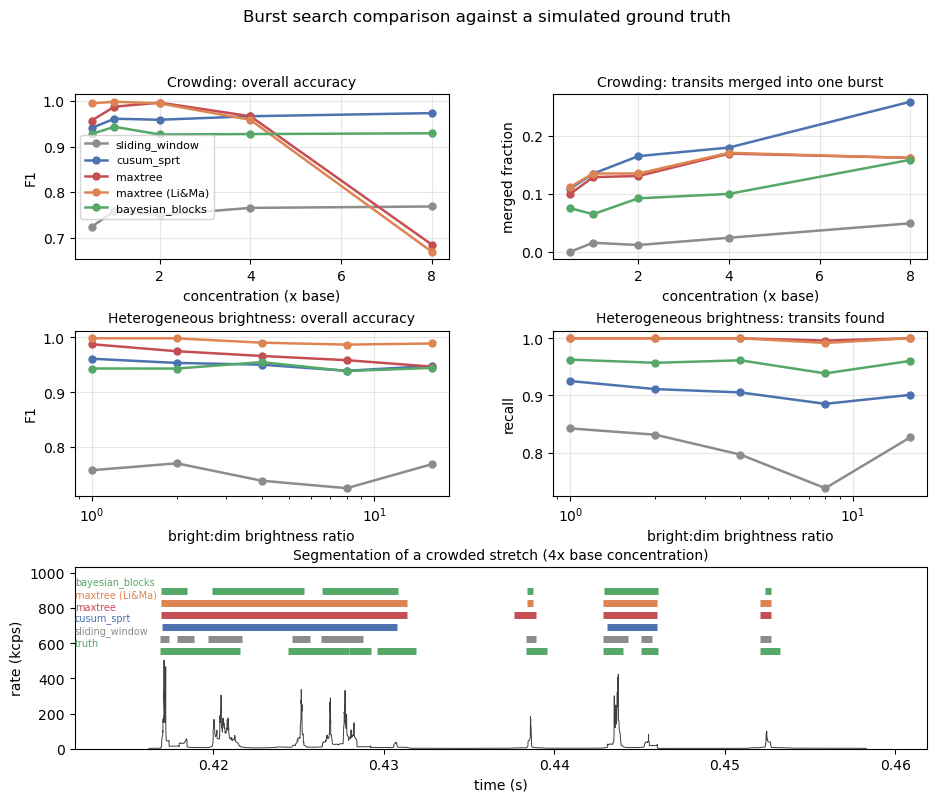

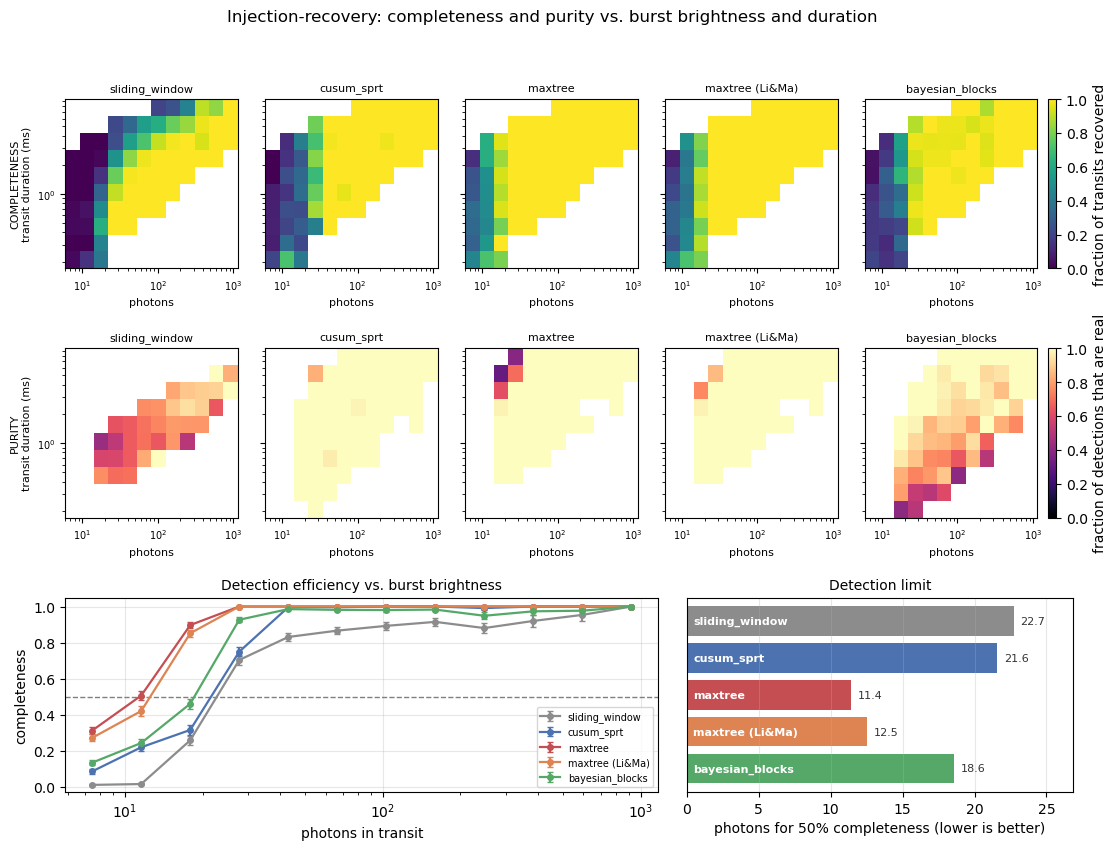

In [28]:
if __name__ == "__main__":
    main()